# Analysis of Global Scientific Production (2000–2024)

In this notebook, we examine the scientific output of the 15 most productive countries according to Scimago Journal & Country Rank (https://www.scimagojr.com/countryrank.php). Using data obtained through Scopus (http://scopus.com), we collect the number of published scientific articles per year from 2000 to 2024 for each country.

The analysis is performed in two complementary ways:
* Absolute production — the total number of articles published each year, showing the evolution of global research output and revealing how different countries have contributed to its growth.

* Normalized production — each country’s publication counts are divided by their respective 2024 value, allowing comparison of relative growth trends independently of total size.

Finally, we compute the median normalized profile across all countries to obtain a representative global trend of scientific production over the past 25 years.

## Results

The median curve shows a distinct **rise-and-fall** pattern in global scientific production between 2000 and 2024.

***

From 2000 to around 2020, the normalized median number of articles increases steadily, with an average annual growth rate of about 4.1 % (slope = 0.041). This long ascent reflects a broad expansion of worldwide research capacity, increased international collaboration, and the continuous growth of indexed journals and research funding.

After peaking near 2020, the trend reverses: the normalized median declines with an average annual decrease of roughly 6.6 % (slope = –0.066). This downturn points to a contraction following two decades of rapid growth. Possible causes include the COVID-19 pandemic’s disruption of research activity, changes in publication incentives, and a slowdown in funding growth in some major economies.

Overall, the curve captures a 20-year phase of expansion followed by a recent and sharper decline, indicating that the remarkable rise in global scientific production that characterized the early 21st century has begun to recede in the most recent years.

In [7]:
!pip install pycountry
import pycountry
import re
import csv
from io import StringIO
import pandas as pd
import matplotlib.pyplot as plt
import glob


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 62.3 MB/s eta 0:00:00


In [3]:
def load_scopus_country_years(path, year_min=2000, year_max=2024):
    """
    Parse a Scopus 'Analyze-Year' CSV file.

    - Extracts the country name from the line
        "Your query : (AFFILCOUNTRY(CountryName))"
    - Converts it to a 2-letter country code using `pycountry` (if available)
    - Returns:
        country_code (str or None), df (columns: 'year', 'count', sorted by year)
      with years restricted to [year_min, year_max].

    Parameters
    ----------
    path : str or Path
        Path to the CSV file.
    year_min, year_max : int
        Inclusive bounds for the years to keep.

    """
    # Read all lines
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # ---- 1) Extract country name from query line ----
    country_name = None
    for line in lines:
        m = re.search(r"AFFILCOUNTRY\(([^)]+)\)", line)
        if m:
            country_name = m.group(1).strip()
            break

    if country_name is None:
        raise ValueError("Could not find AFFILCOUNTRY(...) in the file.")

    # ---- 2) Map country name -> ISO alpha-2 code (2 letters) ----
    # Requires: pip install pycountry
    country_code = None
    try:
        import pycountry  # type: ignore

        try:
            country = pycountry.countries.lookup(country_name)
            country_code = country.alpha_2
        except LookupError:
            # If the name is weird or not found, we leave country_code as None
            country_code = None
    except Exception:
        # pycountry not installed or other problem
        country_code = None

    # ---- 3) Find the "YEAR" header line ----
    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('"YEAR"'):
            start_idx = i + 1  # data starts on next line
            break

    if start_idx is None:
        raise ValueError('Could not find a line starting with "YEAR" in the file.')

    # ---- 4) Parse year/count rows and filter by [year_min, year_max] ----
    records = []
    for line in lines[start_idx:]:
        if not line.strip():
            continue  # skip empty lines
        row = next(csv.reader([line]))
        if len(row) < 2:
            continue
        year_str, count_str = row[0], row[1]
        try:
            year = int(year_str)
            count = int(count_str)
        except ValueError:
            continue  # skip lines that don't have numeric year/count
        if year_min <= year <= year_max:
            records.append({"year": year, "count": count})

    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values("year").reset_index(drop=True)
        df["year"] = df["year"].astype(int)
        df["count"] = df["count"].astype(int)

    return country_code, df

In [12]:
works = {}
for fn in glob.glob("*.csv"):
    country, df = load_scopus_country_years(fn)
    works[country] = df


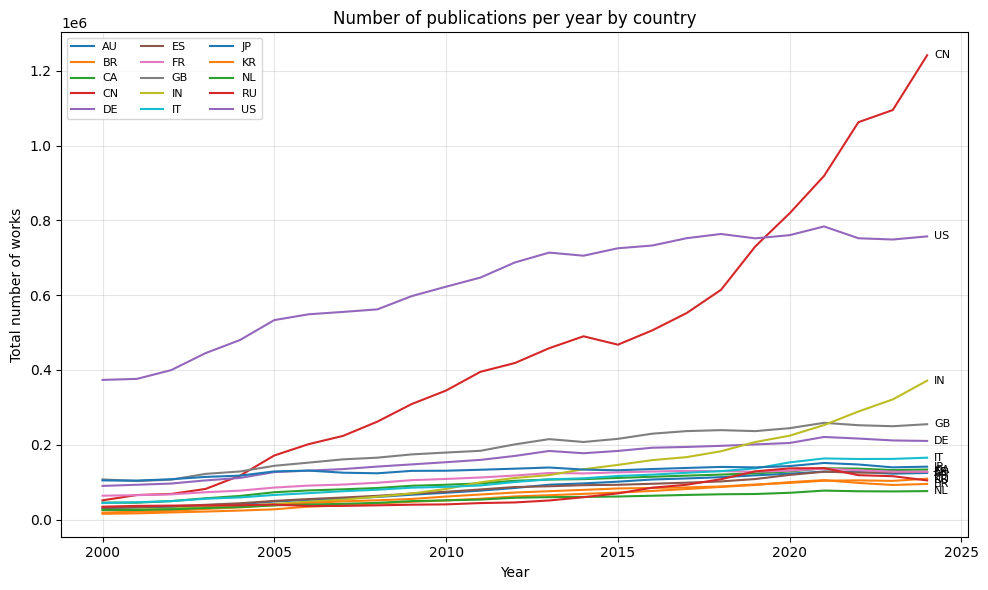

In [16]:
def plot_country_publications(country_dfs, title, ylabel, labelPosition):
    """
    country_dfs: dict like {'US': dfUS, 'CN': dfCN, ...}
                 each df has columns ['year', 'count']
    """
    plt.figure(figsize=(10,6))

    for country, df in sorted(country_dfs.items()):
        df_sorted = df.sort_values("year")
        plt.plot(df_sorted["year"], df_sorted["count"], label=country, linewidth=1.5)

        if labelPosition==1:
          # Add label at the end of the line (rightmost point)
          x = df_sorted["year"].iloc[-1]
          y = df_sorted["count"].iloc[-1]
          plt.text(x + 0.2, y, country, fontsize=8, va='center')
        elif labelPosition==-1:
          # Add label at the end of the line (leftmost point)
          x = df_sorted["year"].iloc[0]
          y = df_sorted["count"].iloc[0]
          plt.text(x - 0.8, y, country, fontsize=8, va='center')

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_country_publications(works, "Number of publications per year by country",
                          "Total number of works", 1)

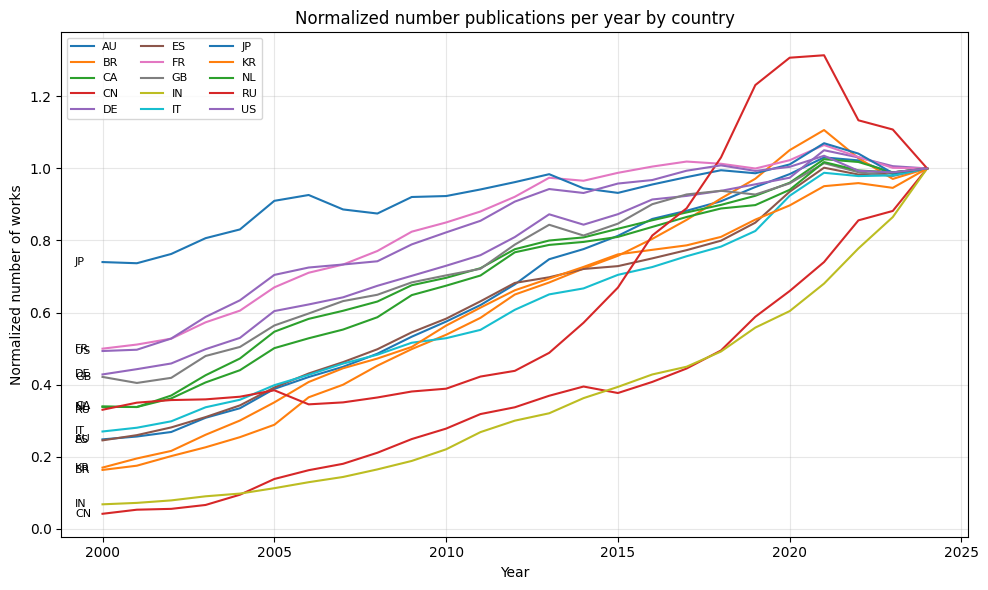

In [17]:
worksNormalized = {
        country: df.assign(count=df["count"] / df["count"].iloc[-1])
        for country, df in works.items()
    }
plot_country_publications(worksNormalized, "Normalized number publications per year by country",
                          "Normalized number of works", -1)

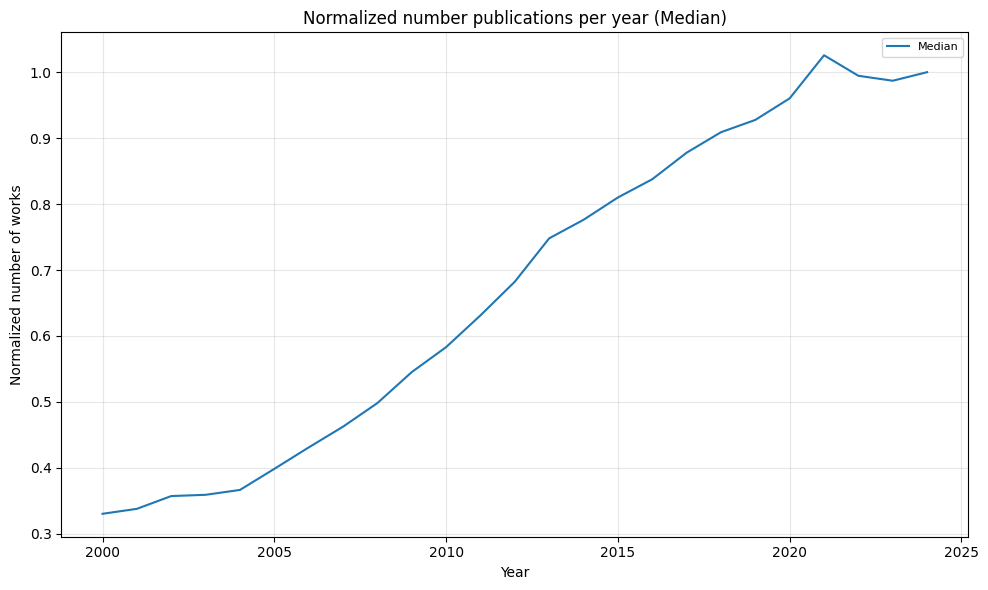

In [18]:
df_all = pd.concat(
    {country: df.set_index("year")["count"] for country, df in worksNormalized.items()},
    axis=1
)

# Compute the median across countries for each year
median_per_year = df_all.median(axis=1, skipna=True)

# Optionally convert to a DataFrame for plotting or export
median_df = median_per_year.reset_index()
median_df.columns = ["year", "count"]

worksMedian = {"Median": median_df}
plot_country_publications(worksMedian, "Normalized number publications per year (Median)",
                          "Normalized number of works", 0)

In [19]:
median_df

,year,count
0,2000,0.330328
1,2001,0.337849
2,2002,0.357216
3,2003,0.359125
4,2004,0.366510
5,2005,0.398449
6,2006,0.430947
7,2007,0.462434
8,2008,0.498242
9,2009,0.545183


In [22]:
slopeUp=(median_df['count'][21]-median_df['count'][0])/21
slopeDown=(median_df['count'][24]-median_df['count'][21])/3
print(f"Slope up={slopeUp}; Slope down={slopeDown}")

Slope up=0.03311001410979085; Slope down=-0.008545987269391523


In [23]:
ratios = (pd.Series({c: (df.set_index("year").loc[2024, "count"] / df.set_index("year").loc[2021, "count"]-1)*100
                     for c, df in works.items()})
          .sort_values(ascending=False))

print("Change from 2021 to 2024 (in %):")
print(ratios.round(1))

Change from 2021 to 2024 (in %):
IN    47.0
CN    35.1
KR     5.2
IT     1.2
ES    -0.2
GB    -1.4
NL    -1.7
CA    -2.5
AU    -3.0
US    -3.4
DE    -4.8
FR    -6.1
JP    -6.5
BR    -9.6
RU   -23.9
dtype: float64


In [24]:
def years_lost_to_2024(df):
    s = df.set_index("year")["count"].dropna()
    if 2024 not in s.index:
        return np.nan, np.nan  # no 2024 data
    c2024 = s.loc[2024]
    # prior years only
    prior = s.loc[s.index <= 2023]
    if prior.empty:
        return np.nan, np.nan
    y_closest = (prior - c2024).abs().idxmin()
    lost = 2024 - y_closest
    return int(lost), int(y_closest)

decliners = ratios[ratios < 0].index
lost_info = {
    c: years_lost_to_2024(works[c]) for c in decliners
}

lost_df = (pd.DataFrame(lost_info, index=["years_lost","closest_year"])
             .T.sort_values("years_lost", ascending=False))

print(lost_df)
print(f"Mean = {lost_df['years_lost'].mean():.1f}")

    years_lost  closest_year
RU           6          2018
JP           6          2018
FR           5          2019
US           4          2020
ES           3          2021
NL           2          2022
GB           2          2022
BR           2          2022
DE           1          2023
CA           1          2023
AU           1          2023
Mean = 3.0
